# UK Enrollments Exploratory Data Analysis (EDA)

This notebook provides a reusable EDA workflow for UK enrollments data.

**Default dataset:** `../data/clean/uk_grouped/with_categorykey/with_category_name/UK_enrollments_grouped_comparison_all_years_with_category.csv`

> Alignment note: when relating UK academic-year data to calendar-year data, this notebook uses the **starting year** of each academic year (for example, `2020/21 → 2020`).
>
> Data correction note: the `2019/20` source originally mixed the narrower `Total UK` field (UK-domiciled students only) with later all-student totals. The cleaned comparison file has been corrected to use the comparable full total for that year.

> You can change `dataset_path` in the next cell if you want to analyze a different UK enrollments file.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

# Resolve the dataset path robustly after moving the notebook into a deeper subfolder
candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
dataset_path = None

for root in candidate_roots:
    candidate = root / "data" / "clean" / "uk_grouped" / "with_categorykey" / "with_category_name" / "UK_enrollments_grouped_comparison_all_years_with_category.csv"
    if candidate.exists():
        dataset_path = candidate
        break

if dataset_path is None:
    raise FileNotFoundError(f"Could not locate the UK enrollments dataset from working directory: {Path.cwd()}")

try:
    df = pd.read_csv(dataset_path)
except UnicodeDecodeError:
    df = pd.read_csv(dataset_path, encoding="latin-1")

print(f"Loaded {dataset_path.name}")
print(f"Resolved path: {dataset_path}")
print(f"Rows: {df.shape[0]:,} | Columns: {df.shape[1]:,}")
display(df.head())

Loaded UK_enrollments_grouped_comparison_all_years_with_category.csv
Resolved path: C:\Users\neddp\ECC3479-Project-JRGS\data\clean\uk_grouped\with_categorykey\with_category_name\UK_enrollments_grouped_comparison_all_years_with_category.csv
Rows: 282 | Columns: 10


,categorykey,Category,Subject,England,Wales,Scotland,Northern Ireland,Other UK,Total UK,AcademicYear
0,1,Natural & Physical Science,03 Biological sciences,167845.0,15150.0,20980.0,3590.0,NaN,207560.0,2013/14
1,1,Natural & Physical Science,07 Mathematical sciences,36330.0,1595.0,3770.0,530.0,NaN,42230.0,2013/14
2,1,Natural & Physical Science,09 Engineering & technology,125925.0,10260.0,19195.0,3630.0,NaN,159010.0,2013/14
3,5,Environment & Related,06 Physical sciences,75165.0,5570.0,10760.0,1820.0,NaN,93320.0,2013/14
4,6,Health,01 Medicine & dentistry,53440.0,4055.0,7745.0,2085.0,NaN,67325.0,2013/14


## 1. Inspect Data Structure

Review the columns, data types, academic years, and the overall structure of the UK enrollments dataset.

In [2]:
print("Column names:")
print(df.columns.tolist())

region_cols = [
    "England",
    "Wales",
    "Scotland",
    "Northern Ireland",
    "Other UK",
    "Total UK",
]

for col in ["categorykey", *region_cols]:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col], errors="coerce")

if "AcademicYear" in df.columns:
    academic_year_order = df["AcademicYear"].dropna().astype(str).drop_duplicates().tolist()
    df["AcademicYear"] = pd.Categorical(df["AcademicYear"].astype(str), categories=academic_year_order, ordered=True)

    def academic_year_to_start_year(label: str) -> int:
        label = str(label)
        if "/" in label:
            start, _ = label.split("/")
            return int(start)
        return int(float(label))

    df["Year"] = df["AcademicYear"].astype(str).apply(academic_year_to_start_year)
    year_mapping = (
        df[["AcademicYear", "Year"]]
        .drop_duplicates()
        .sort_values("Year")
        .reset_index(drop=True)
    )
else:
    academic_year_order = []
    df["Year"] = np.nan
    year_mapping = pd.DataFrame()

print(f"\nAcademic years: {academic_year_order}")
if not year_mapping.empty:
    print("\nAcademic year alignment (start year):")
    display(year_mapping)

print("\nData types:")
display(df.dtypes.to_frame("dtype"))

print(f"\nShape: {df.shape}")
print("\nDataset info:")
df.info()

print("\nPreview:")
display(df.head())

Column names:
['categorykey', 'Category', 'Subject', 'England', 'Wales', 'Scotland', 'Northern Ireland', 'Other UK', 'Total UK', 'AcademicYear']

Academic years: ['2013/14', '2014/15', '2015/16', '2016/17', '2017/18', '2018/19', '2019/20', '2020/21', '2021/22', '2022/23', '2023/24', '2024/25']

Academic year alignment (start year):


,AcademicYear,Year
0,2013/14,2013
1,2014/15,2014
2,2015/16,2015
3,2016/17,2016
4,2017/18,2017
5,2018/19,2018
6,2019/20,2019
7,2020/21,2020
8,2021/22,2021
9,2022/23,2022



Data types:


,dtype
categorykey,int64
Category,str
Subject,str
England,float64
Wales,float64
Scotland,float64
Northern Ireland,float64
Other UK,float64
Total UK,float64
AcademicYear,category



Shape: (282, 11)

Dataset info:
<class 'pandas.DataFrame'>
RangeIndex: 282 entries, 0 to 281
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   categorykey       282 non-null    int64   
 1   Category          282 non-null    str     
 2   Subject           282 non-null    str     
 3   England           282 non-null    float64 
 4   Wales             276 non-null    float64 
 5   Scotland          282 non-null    float64 
 6   Northern Ireland  276 non-null    float64 
 7   Other UK          25 non-null     float64 
 8   Total UK          282 non-null    float64 
 9   AcademicYear      282 non-null    category
 10  Year              282 non-null    int64   
dtypes: category(1), float64(6), int64(2), str(2)
memory usage: 22.8 KB

Preview:


,categorykey,Category,Subject,England,Wales,Scotland,Northern Ireland,Other UK,Total UK,AcademicYear,Year
0,1,Natural & Physical Science,03 Biological sciences,167845.0,15150.0,20980.0,3590.0,NaN,207560.0,2013/14,2013
1,1,Natural & Physical Science,07 Mathematical sciences,36330.0,1595.0,3770.0,530.0,NaN,42230.0,2013/14,2013
2,1,Natural & Physical Science,09 Engineering & technology,125925.0,10260.0,19195.0,3630.0,NaN,159010.0,2013/14,2013
3,5,Environment & Related,06 Physical sciences,75165.0,5570.0,10760.0,1820.0,NaN,93320.0,2013/14,2013
4,6,Health,01 Medicine & dentistry,53440.0,4055.0,7745.0,2085.0,NaN,67325.0,2013/14,2013


## 2. Clean Missing Values and Duplicates

Check for missing values and duplicate rows, then create a cleaned copy for analysis.

In [3]:
missing_summary = df.isna().sum().sort_values(ascending=False)
missing_summary = missing_summary[missing_summary > 0]

print("Missing values by column:")
if missing_summary.empty:
    display(pd.DataFrame({"message": ["No missing values found"]}))
else:
    display(missing_summary.to_frame("missing_count"))

duplicate_count = int(df.duplicated().sum())
print(f"Duplicate rows: {duplicate_count}")

df_clean = df.drop_duplicates().copy()
for col in region_cols:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].fillna(0)

df_clean_no_total = df_clean[df_clean["Category"] != "Total"].copy() if "Category" in df_clean.columns else df_clean.copy()

print(f"Shape after cleaning: {df_clean.shape}")
print(f"Shape excluding total rows: {df_clean_no_total.shape}")

Missing values by column:


,missing_count
Other UK,257
Wales,6
Northern Ireland,6


Duplicate rows: 0
Shape after cleaning: (282, 11)
Shape excluding total rows: (246, 11)


## 3. Compute Summary Statistics

Summarize enrollments across regions, categories, subjects, and academic years.

In [4]:
numeric_cols = [col for col in [*region_cols, "categorykey", "Year"] if col in df_clean.columns]
categorical_cols = [col for col in ["Category", "Subject", "AcademicYear"] if col in df_clean.columns]

print(f"Numeric columns ({len(numeric_cols)}):", numeric_cols)
print(f"Categorical columns ({len(categorical_cols)}):", categorical_cols)

if numeric_cols:
    display(df_clean[numeric_cols].describe().T)
else:
    print("No numeric columns available for summary statistics.")

if {"Year", "Category", "Total UK"}.issubset(df_clean_no_total.columns):
    category_year = (
        df_clean_no_total.groupby(["Year", "Category"], observed=True)["Total UK"]
        .sum()
        .reset_index()
    )
    display(category_year.head())

    latest_year = int(df_clean_no_total["Year"].max())
    latest_year_label = (
        df_clean_no_total.loc[df_clean_no_total["Year"] == latest_year, "AcademicYear"]
        .astype(str)
        .mode()
        .iloc[0]
        if "AcademicYear" in df_clean_no_total.columns
        else str(latest_year)
    )
    latest_category_ranking = category_year[category_year["Year"] == latest_year].sort_values("Total UK", ascending=False)
    print(f"\nCategory totals in {latest_year_label} (start year {latest_year}):")
    display(latest_category_ranking)

    if {"Subject", "AcademicYear"}.issubset(df_clean_no_total.columns):
        top_subjects_latest = (
            df_clean_no_total[df_clean_no_total["Year"] == latest_year]
            [["Category", "Subject", "Total UK"]]
            .sort_values("Total UK", ascending=False)
            .head(10)
        )
        print(f"\nTop subjects in {latest_year_label}:")
        display(top_subjects_latest)

Numeric columns (8): ['England', 'Wales', 'Scotland', 'Northern Ireland', 'Other UK', 'Total UK', 'categorykey', 'Year']
Categorical columns (3): ['Category', 'Subject', 'AcademicYear']


,count,mean,std,min,25%,50%,75%,max
England,282.0,263444.361702,474006.086275,4345.0,41831.25,83285.0,182287.50,2423140.0
Wales,282.0,17411.382979,31064.925053,0.0,2643.75,6045.0,12470.00,154385.0
Scotland,282.0,32436.755319,57963.801552,495.0,6187.50,11790.0,21688.75,301230.0
Northern Ireland,282.0,7642.872340,13669.079404,0.0,1137.50,2207.5,5887.50,67515.0
Other UK,282.0,47.287234,330.031540,0.0,0.00,0.0,0.00,4450.0
Total UK,282.0,326881.258865,585190.263842,5900.0,50516.25,109120.0,225223.75,2937285.0
categorykey,282.0,18.829787,30.902661,1.0,5.00,9.0,11.00,99.0
Year,282.0,2018.691489,3.452865,2013.0,2016.00,2019.0,2022.00,2024.0


,Year,Category,Total UK
0,2013,Environment & Related,93320.0
1,2013,Health,358930.0
2,2013,Natural & Physical Science,408800.0
3,2013,Others,1432480.0
4,2013,Society & Culture,5935.0



Category totals in 2024/25 (start year 2024):


,Year,Category,Total UK
95,2024,Society & Culture,757820.0
92,2024,Management & Commerce,586710.0
90,2024,Health,458465.0
93,2024,Natural & Physical Science,220430.0
91,2024,Information Technology,205990.0
86,2024,Creative Arts,178755.0
88,2024,Engineering & Related Tech,176530.0
87,2024,Education,109885.0
85,2024,Architecture & Building,67475.0
89,2024,Environment & Related,61915.0



Top subjects in 2024/25:


,Category,Subject,Total UK
270,Management & Commerce,17 Business and management,586710.0
267,Health,02 Subjects allied to medicine,360360.0
272,Society & Culture,15 Social sciences,275900.0
260,Information Technology,11 Computing,205990.0
277,Creative Arts,"25 Design, and creative and performing arts",178755.0
261,Engineering & Related Tech,10 Engineering and technology,176530.0
273,Society & Culture,16 Law,144525.0
271,Society & Culture,04 Psychology,138290.0
257,Natural & Physical Science,03 Biological and sport sciences,111380.0
269,Education,22 Education and teaching,109885.0


## 4. Visualize UK Enrollment Trends

Plot total UK enrollments over time, compare category trends, and show Tukey box plots by category.

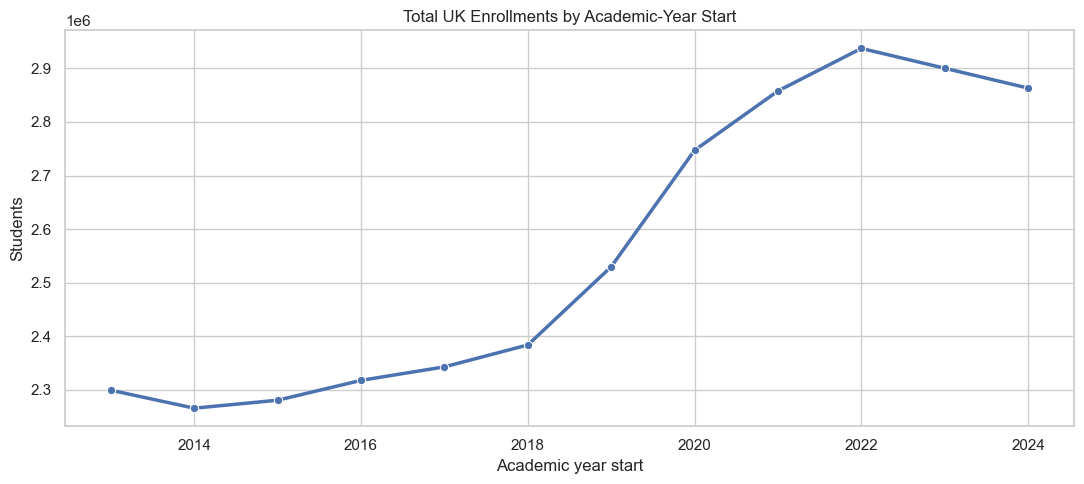

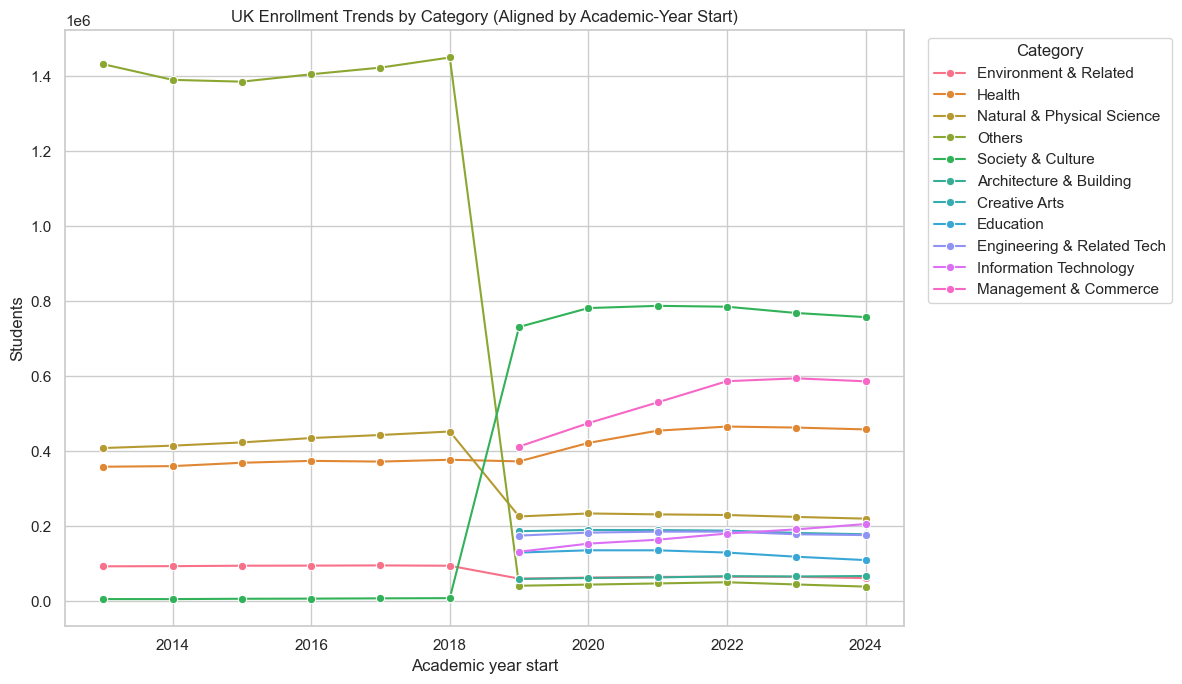

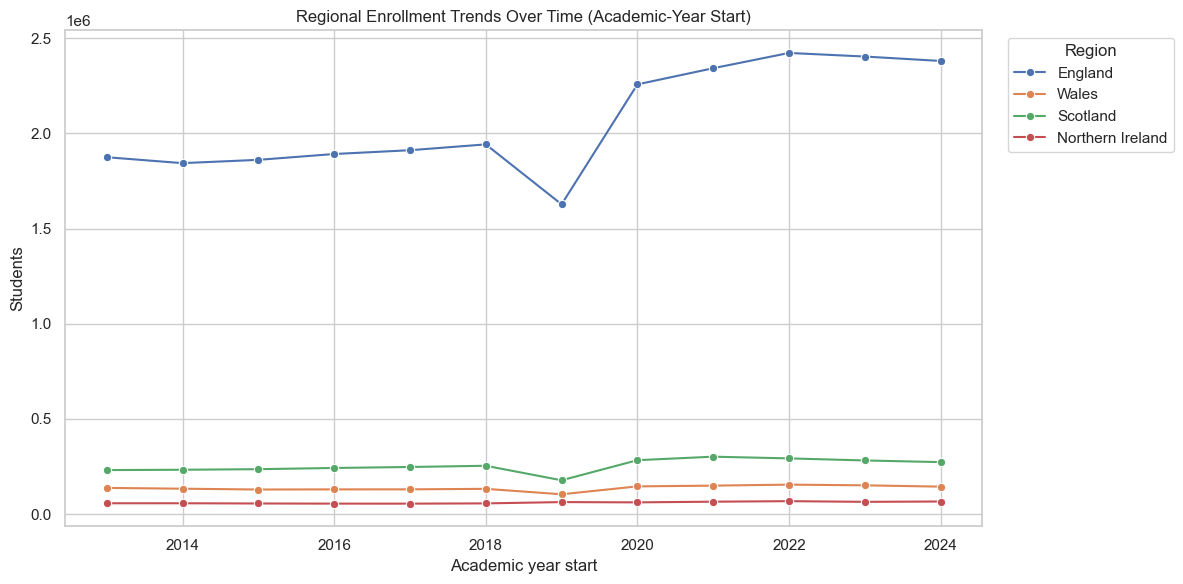

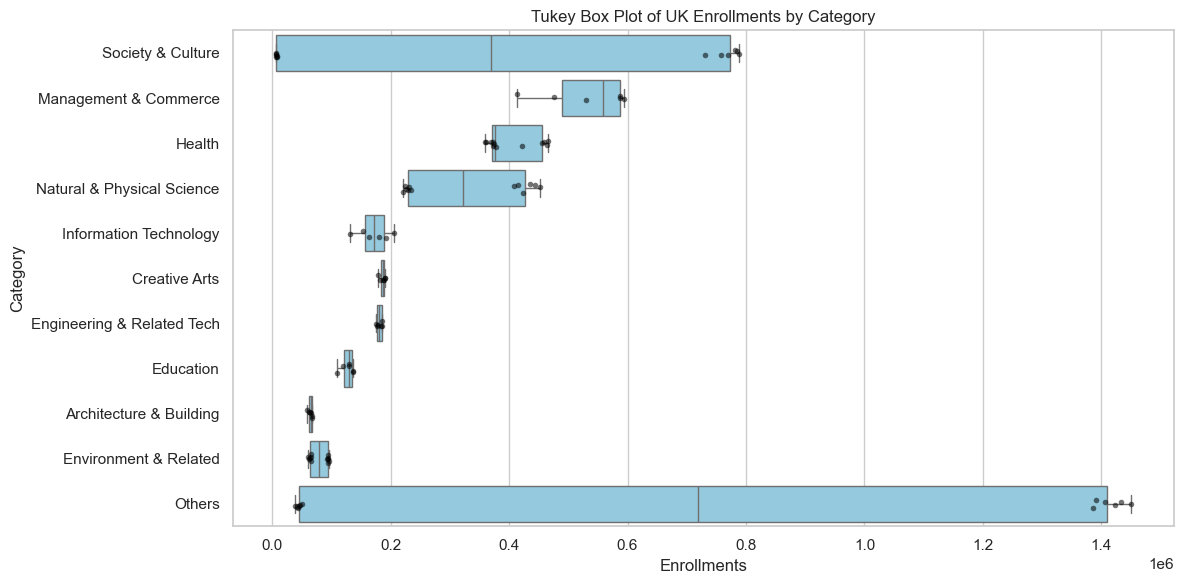

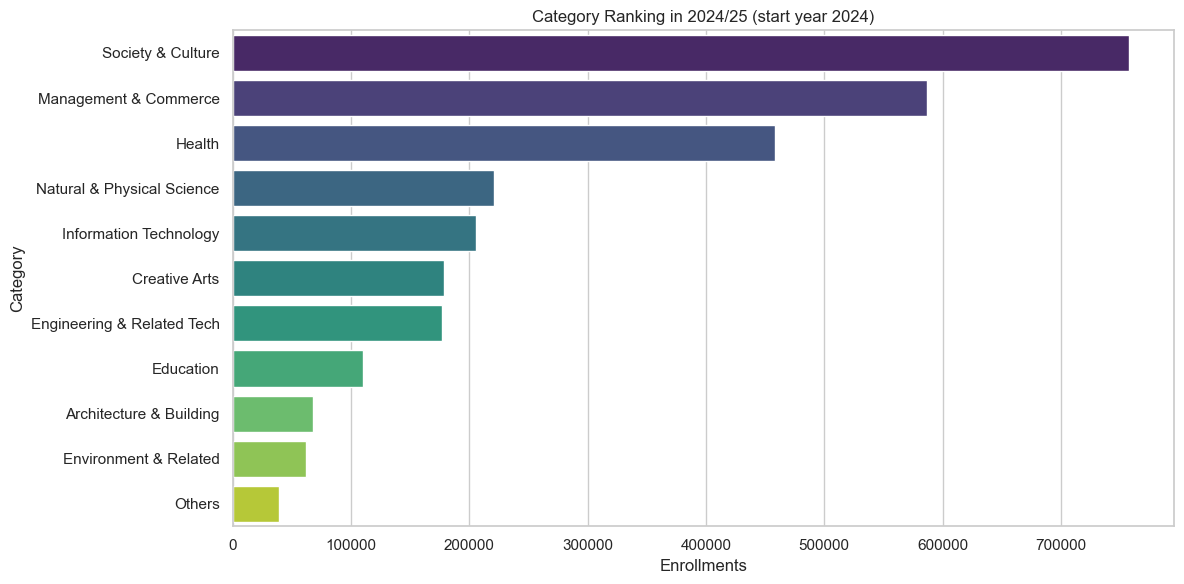

In [5]:
if {"Year", "Category", "Total UK"}.issubset(df_clean_no_total.columns):
    category_year = (
        df_clean_no_total.groupby(["Year", "Category"], observed=True)["Total UK"]
        .sum()
        .reset_index()
    )

    overall_yearly_totals = df_clean[
        (df_clean["Category"].astype(str) == "Total")
        & (df_clean["Subject"].astype(str) == "Total")
    ][["Year", "Total UK"]].copy()

    if overall_yearly_totals.empty:
        overall_yearly_totals = (
            df_clean_no_total.groupby("Year", observed=True)["Total UK"]
            .sum()
            .reset_index()
        )

    latest_year = int(df_clean_no_total["Year"].max())
    latest_year_label = (
        df_clean_no_total.loc[df_clean_no_total["Year"] == latest_year, "AcademicYear"]
        .astype(str)
        .mode()
        .iloc[0]
        if "AcademicYear" in df_clean_no_total.columns
        else str(latest_year)
    )
    latest_category_ranking = category_year[category_year["Year"] == latest_year].sort_values("Total UK", ascending=False)
    category_order = latest_category_ranking["Category"].tolist()

    plt.figure(figsize=(11, 5))
    sns.lineplot(data=overall_yearly_totals.sort_values("Year"), x="Year", y="Total UK", marker="o", linewidth=2.5)
    plt.title("Total UK Enrollments by Academic-Year Start")
    plt.xlabel("Academic year start")
    plt.ylabel("Students")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 7))
    sns.lineplot(data=category_year.sort_values("Year"), x="Year", y="Total UK", hue="Category", marker="o")
    plt.title("UK Enrollment Trends by Category (Aligned by Academic-Year Start)")
    plt.xlabel("Academic year start")
    plt.ylabel("Students")
    plt.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
    plt.tight_layout()
    plt.show()

    region_cols_present = [col for col in ["England", "Wales", "Scotland", "Northern Ireland"] if col in df_clean_no_total.columns]
    if region_cols_present:
        region_year = (
            df_clean_no_total.groupby("Year", observed=True)[region_cols_present]
            .sum()
            .reset_index()
        )
        region_year_long = region_year.melt(id_vars="Year", var_name="Region", value_name="Enrollments")

        plt.figure(figsize=(12, 6))
        sns.lineplot(data=region_year_long.sort_values("Year"), x="Year", y="Enrollments", hue="Region", marker="o")
        plt.title("Regional Enrollment Trends Over Time (Academic-Year Start)")
        plt.xlabel("Academic year start")
        plt.ylabel("Students")
        plt.legend(title="Region", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        plt.show()

    plt.figure(figsize=(12, 6))
    sns.boxplot(data=category_year, x="Total UK", y="Category", order=category_order, whis=1.5, color="skyblue")
    sns.stripplot(data=category_year, x="Total UK", y="Category", order=category_order, color="black", alpha=0.55, size=4)
    plt.title("Tukey Box Plot of UK Enrollments by Category")
    plt.xlabel("Enrollments")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(12, 6))
    sns.barplot(data=latest_category_ranking, x="Total UK", y="Category", hue="Category", palette="viridis", legend=False)
    plt.title(f"Category Ranking in {latest_year_label} (start year {latest_year})")
    plt.xlabel("Enrollments")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()
else:
    print("The required columns for UK trend visualizations are not available.")

## 5. Explore Correlations Across Regions

Check how enrollment counts in the UK regions move together using a correlation heatmap.

,England,Wales,Scotland,Northern Ireland,Total UK
England,1.000000,0.940621,0.945063,0.912154,0.992953
Wales,0.940621,1.000000,0.953310,0.890600,0.942868
Scotland,0.945063,0.953310,1.000000,0.917569,0.947556
Northern Ireland,0.912154,0.890600,0.917569,1.000000,0.924124
Total UK,0.992953,0.942868,0.947556,0.924124,1.000000


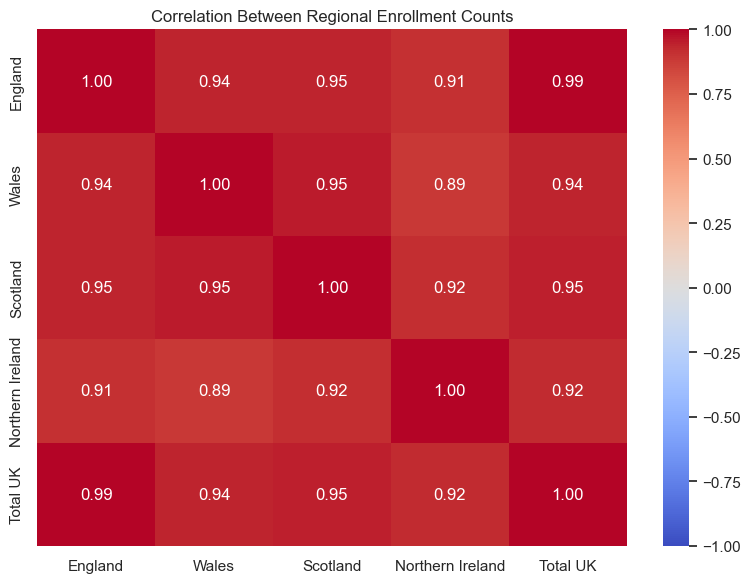

In [6]:
region_corr_cols = [col for col in ["England", "Wales", "Scotland", "Northern Ireland", "Total UK"] if col in df_clean_no_total.columns]

if len(region_corr_cols) >= 2:
    corr_matrix = df_clean_no_total[region_corr_cols].corr(numeric_only=True)
    display(corr_matrix)

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", vmin=-1, vmax=1)
    plt.title("Correlation Between Regional Enrollment Counts")
    plt.tight_layout()
    plt.show()
else:
    print("At least two numeric regional columns are needed to compute correlations.")

## 6. Identify Fast-Growing and Unusual Categories

Measure how category totals changed from the **earliest available year to the latest available year for each category** and flag unusually large movements.

> Note: some UK category groupings change across years, so a few categories have partial time coverage rather than a full 2013/14–2024/25 span.

,Category,First Year,Last Year,First Total UK,Last Total UK,Absolute Change,Percent Change,Coverage,Potential Outlier
10,Society & Culture,2013/14,2024/25,5935.0,757820.0,751885.0,12668.66,Full span,True
7,Management & Commerce,2019/20,2024/25,412850.0,586710.0,173860.0,42.11,Partial span,False
5,Health,2013/14,2024/25,358930.0,458465.0,99535.0,27.73,Full span,False
6,Information Technology,2019/20,2024/25,132145.0,205990.0,73845.0,55.88,Partial span,False
0,Architecture & Building,2019/20,2024/25,59575.0,67475.0,7900.0,13.26,Partial span,False
3,Engineering & Related Tech,2019/20,2024/25,175255.0,176530.0,1275.0,0.73,Partial span,False
1,Creative Arts,2019/20,2024/25,187045.0,178755.0,-8290.0,-4.43,Partial span,False
2,Education,2019/20,2024/25,129965.0,109885.0,-20080.0,-15.45,Partial span,False
4,Environment & Related,2013/14,2024/25,93320.0,61915.0,-31405.0,-33.65,Full span,False
8,Natural & Physical Science,2013/14,2024/25,408800.0,220430.0,-188370.0,-46.08,Full span,False


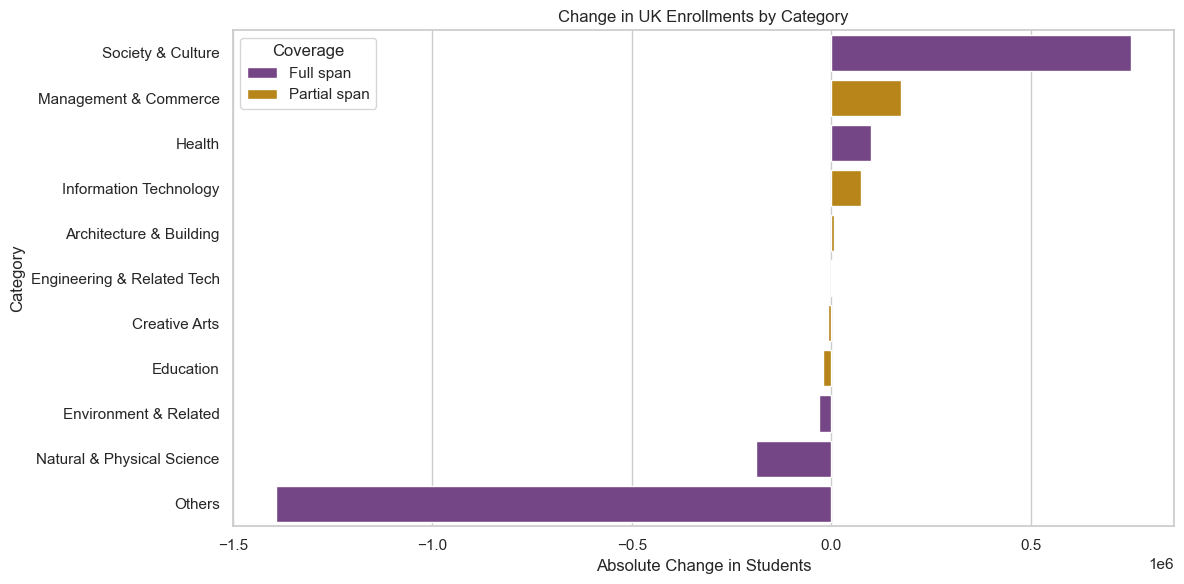

Outlier bounds for absolute change: lower=-194391.25, upper=255338.75

Categories with partial year coverage:


,Category,First Year,Last Year,First Total UK,Last Total UK,Absolute Change,Percent Change,Coverage,Potential Outlier
7,Management & Commerce,2019/20,2024/25,412850.0,586710.0,173860.0,42.11,Partial span,False
6,Information Technology,2019/20,2024/25,132145.0,205990.0,73845.0,55.88,Partial span,False
0,Architecture & Building,2019/20,2024/25,59575.0,67475.0,7900.0,13.26,Partial span,False
3,Engineering & Related Tech,2019/20,2024/25,175255.0,176530.0,1275.0,0.73,Partial span,False
1,Creative Arts,2019/20,2024/25,187045.0,178755.0,-8290.0,-4.43,Partial span,False
2,Education,2019/20,2024/25,129965.0,109885.0,-20080.0,-15.45,Partial span,False



Potential outliers in category change:


,Category,First Year,Last Year,First Total UK,Last Total UK,Absolute Change,Percent Change,Coverage,Potential Outlier
10,Society & Culture,2013/14,2024/25,5935.0,757820.0,751885.0,12668.66,Full span,True
9,Others,2013/14,2024/25,1432480.0,39200.0,-1393280.0,-97.26,Full span,True


In [7]:
if {"AcademicYear", "Category", "Total UK"}.issubset(df_clean_no_total.columns):
    category_year_growth = (
        df_clean_no_total.groupby(["AcademicYear", "Category"], observed=True)["Total UK"]
        .sum()
        .reset_index()
    )
    category_year_growth["AcademicYear"] = category_year_growth["AcademicYear"].astype(str)

    growth_rows = []
    ordered_years = academic_year_order if academic_year_order else sorted(category_year_growth["AcademicYear"].unique().tolist())

    for category, group in category_year_growth.groupby("Category", observed=True):
        group = group.copy()
        group["AcademicYear"] = pd.Categorical(group["AcademicYear"], categories=ordered_years, ordered=True)
        group = group.sort_values("AcademicYear")
        group = group.dropna(subset=["Total UK"])

        if group.empty:
            continue

        first_row = group.iloc[0]
        last_row = group.iloc[-1]
        first_value = float(first_row["Total UK"])
        last_value = float(last_row["Total UK"])
        absolute_change = last_value - first_value
        percent_change = (absolute_change / first_value * 100) if first_value != 0 else np.nan

        growth_rows.append({
            "Category": category,
            "First Year": str(first_row["AcademicYear"]),
            "Last Year": str(last_row["AcademicYear"]),
            "First Total UK": first_value,
            "Last Total UK": last_value,
            "Absolute Change": absolute_change,
            "Percent Change": round(percent_change, 2) if pd.notna(percent_change) else np.nan,
        })

    growth_df = pd.DataFrame(growth_rows).sort_values("Absolute Change", ascending=False)
    growth_df["Coverage"] = np.where(
        (growth_df["First Year"] == ordered_years[0]) & (growth_df["Last Year"] == ordered_years[-1]),
        "Full span",
        "Partial span",
    )

    q1 = growth_df["Absolute Change"].quantile(0.25)
    q3 = growth_df["Absolute Change"].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    growth_df["Potential Outlier"] = ~growth_df["Absolute Change"].between(lower, upper, inclusive="both")

    display(growth_df)

    plt.figure(figsize=(12, 6))
    sns.barplot(
        data=growth_df.sort_values("Absolute Change", ascending=False),
        x="Absolute Change",
        y="Category",
        hue="Coverage",
        dodge=False,
        palette={"Full span": "#7a3b8f", "Partial span": "#d18f00"},
    )
    plt.title("Change in UK Enrollments by Category")
    plt.xlabel("Absolute Change in Students")
    plt.ylabel("Category")
    plt.tight_layout()
    plt.show()

    print(f"Outlier bounds for absolute change: lower={lower:.2f}, upper={upper:.2f}")
    print("\nCategories with partial year coverage:")
    display(growth_df[growth_df["Coverage"] == "Partial span"])

    print("\nPotential outliers in category change:")
    display(growth_df[growth_df["Potential Outlier"]])
else:
    print("Category and academic year columns are required for growth analysis.")

## 7. Separate Tukey Box Plots by Area of Study

Show one independent Tukey box plot for each UK study area, based on its totals across academic years.

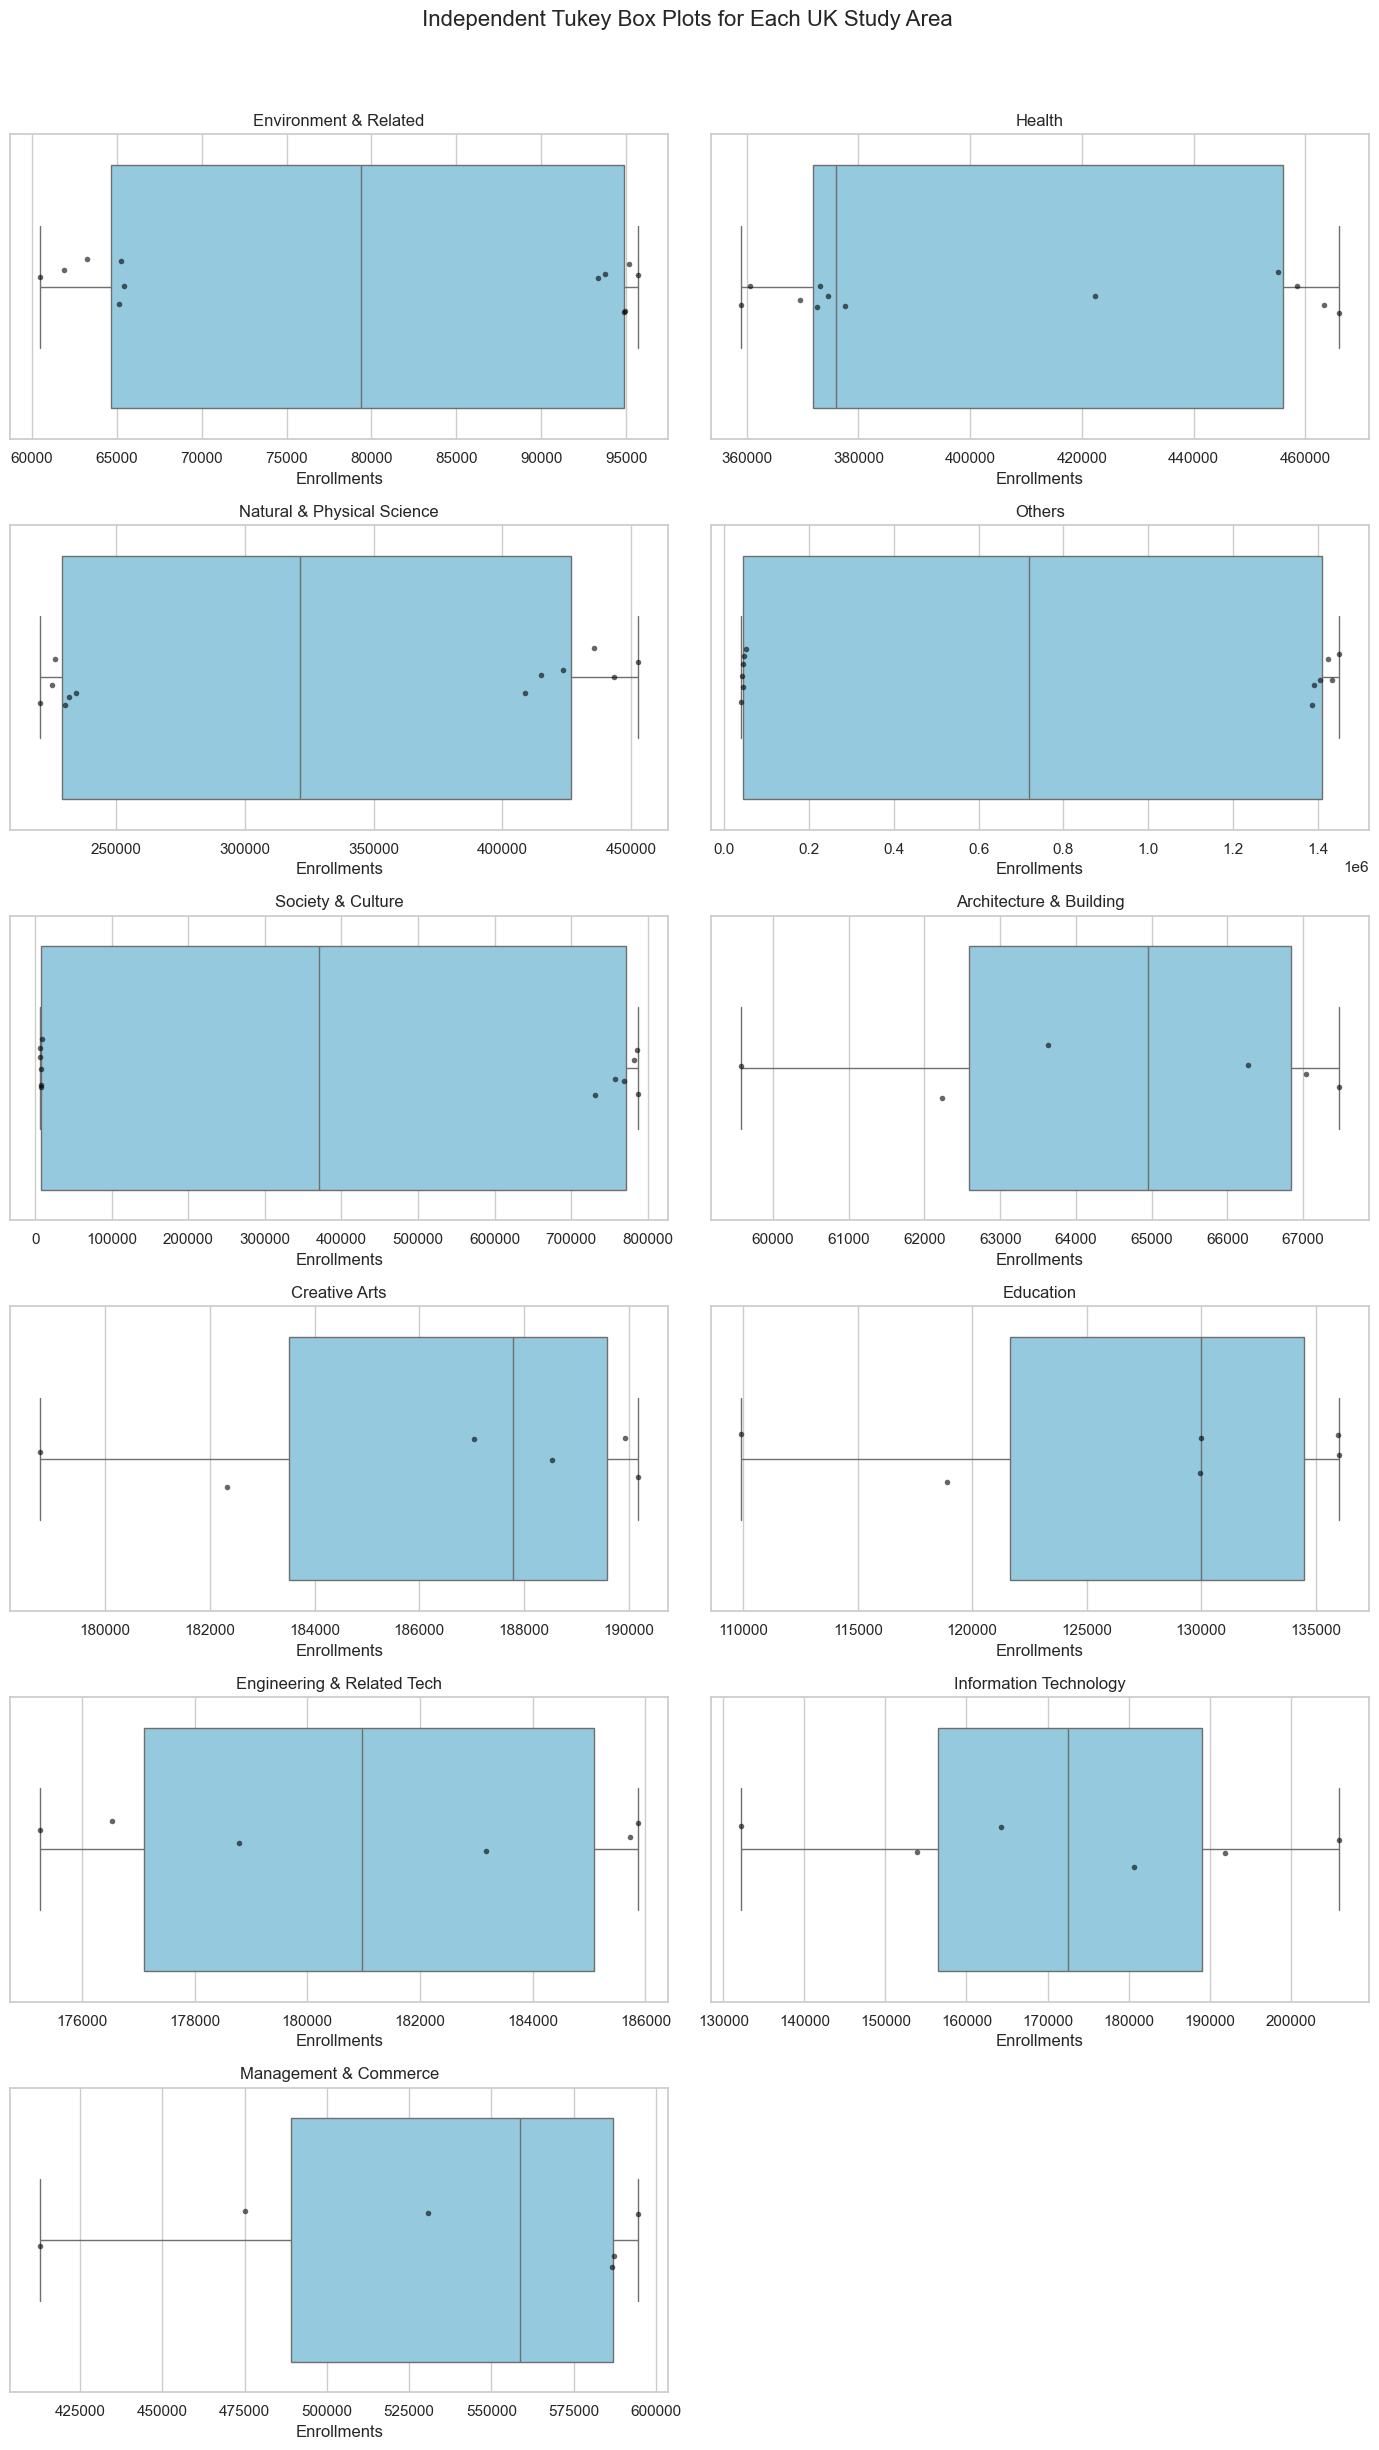

In [8]:
if {"AcademicYear", "Category", "Total UK"}.issubset(df_clean_no_total.columns):
    category_year_box = (
        df_clean_no_total.groupby(["AcademicYear", "Category"], observed=True)["Total UK"]
        .sum()
        .reset_index()
    )
    category_year_box["AcademicYear"] = category_year_box["AcademicYear"].astype(str)

    categories = category_year_box["Category"].dropna().unique().tolist()
    n_cols = 2
    n_rows = (len(categories) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4 * n_rows), sharex=False)
    axes = np.array(axes).reshape(-1)

    for ax, category in zip(axes, categories):
        cat_values = category_year_box.loc[category_year_box["Category"] == category, "Total UK"].dropna()

        sns.boxplot(x=cat_values, ax=ax, whis=1.5, color="skyblue")
        sns.stripplot(x=cat_values, ax=ax, color="black", alpha=0.6, size=4)
        ax.set_title(category)
        ax.set_xlabel("Enrollments")
        ax.set_yticks([])

    for ax in axes[len(categories):]:
        ax.set_visible(False)

    plt.suptitle("Independent Tukey Box Plots for Each UK Study Area", y=1.02, fontsize=16)
    plt.tight_layout()
    plt.show()
else:
    print("Category data is required to create separate Tukey box plots.")

## 8. Summary Table of Total Enrollments by Year

A compact table showing the total UK enrollments for each academic-year start.

In [9]:
if {"Year", "Total UK"}.issubset(df_clean.columns):
    yearly_totals_summary = df_clean.loc[
        (df_clean["Category"].astype(str) == "Total")
        & (df_clean["Subject"].astype(str) == "Total"),
        [col for col in ["Year", "AcademicYear", "Total UK"] if col in df_clean.columns],
    ].drop_duplicates()

    if yearly_totals_summary.empty:
        yearly_totals_summary = (
            df_clean_no_total.groupby("Year", observed=True)["Total UK"]
            .sum()
            .reset_index()
        )
        if "AcademicYear" in df_clean.columns:
            year_labels = (
                df_clean[["Year", "AcademicYear"]]
                .dropna()
                .drop_duplicates()
                .sort_values("Year")
            )
            yearly_totals_summary = yearly_totals_summary.merge(year_labels, on="Year", how="left")

    yearly_totals_summary = yearly_totals_summary.rename(
        columns={
            "Year": "Start Year",
            "AcademicYear": "Academic Year",
            "Total UK": "Total Enrollments",
        }
    ).sort_values("Start Year").reset_index(drop=True)

    if "Total Enrollments" in yearly_totals_summary.columns:
        yearly_totals_summary["Total Enrollments"] = yearly_totals_summary["Total Enrollments"].round(0).astype(int)

    display(yearly_totals_summary.style.format({"Total Enrollments": "{:,}"}))
else:
    print("The cleaned UK totals are not available for the yearly summary table.")

,Start Year,Academic Year,Total Enrollments
0,2013,2013/14,"2,299,460"
1,2014,2014/15,"2,265,980"
2,2015,2015/16,"2,280,830"
3,2016,2016/17,"2,317,880"
4,2017,2017/18,"2,343,095"
5,2018,2018/19,"2,383,970"
6,2019,2019/20,"2,529,870"
7,2020,2020/21,"2,747,200"
8,2021,2021/22,"2,857,855"
9,2022,2022/23,"2,937,285"


## 9. Additional Statistical Checks

This section checks for correlation, nonlinearity, heterogeneity, and subgroup differences in UK enrollments.

In [10]:
# Prepare UK enrollment data for additional checks
try:
    from scipy import stats
except ImportError:
    stats = None
    print('scipy is not installed; inferential tests will be skipped.')

analysis_uk = (
    df_clean_no_total.groupby(['Year', 'Category'], observed=True)['Total UK']
    .sum()
    .reset_index()
    .sort_values(['Year', 'Category'])
)

overall_uk = (
    analysis_uk.groupby('Year', as_index=False)['Total UK']
    .sum()
    .sort_values('Year')
)

display(analysis_uk.head())
print(f'Rows available for checks: {len(analysis_uk)}')

,Year,Category,Total UK
0,2013,Environment & Related,93320.0
1,2013,Health,358930.0
2,2013,Natural & Physical Science,408800.0
3,2013,Others,1432480.0
4,2013,Society & Culture,5935.0


Rows available for checks: 96


In [11]:
# Correlation checks
pearson_year_total = overall_uk[['Year', 'Total UK']].corr(method='pearson').iloc[0, 1]
spearman_year_total = overall_uk[['Year', 'Total UK']].corr(method='spearman').iloc[0, 1]

print(f'Pearson correlation between Year and Total UK enrollments: {pearson_year_total:.4f}')
print(f'Spearman correlation between Year and Total UK enrollments: {spearman_year_total:.4f}')

category_corr = (
    analysis_uk.groupby('Category')
    .apply(lambda g: g['Year'].corr(g['Total UK']) if g['Year'].nunique() > 1 else np.nan)
    .reset_index(name='Year_vs_TotalUK_corr')
    .sort_values('Year_vs_TotalUK_corr', ascending=False)
)

print('Category-level correlation between Year and Total UK enrollments')
display(category_corr)

Pearson correlation between Year and Total UK enrollments: 0.9361
Spearman correlation between Year and Total UK enrollments: 0.9510
Category-level correlation between Year and Total UK enrollments


,Category,Year_vs_TotalUK_corr
6,Information Technology,0.995227
0,Architecture & Building,0.944512
7,Management & Commerce,0.927713
5,Health,0.916417
10,Society & Culture,0.871873
3,Engineering & Related Tech,-0.075706
1,Creative Arts,-0.769708
2,Education,-0.812810
8,Natural & Physical Science,-0.832761
4,Environment & Related,-0.844301


Linear fit R^2: 0.8762
Quadratic fit R^2: 0.8876
The UK enrollment trend appears mostly linear over time.


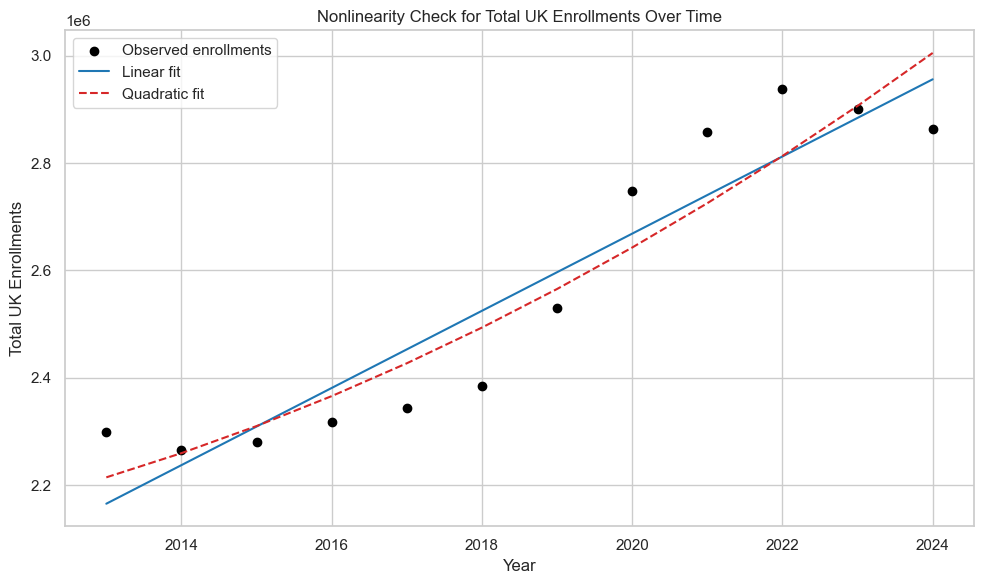

In [12]:
# Nonlinearity check: linear vs quadratic trend in total UK enrollments
x = overall_uk['Year'].to_numpy(dtype=float)
y = overall_uk['Total UK'].to_numpy(dtype=float)

lin_coef = np.polyfit(x, y, 1)
quad_coef = np.polyfit(x, y, 2)
lin_pred = np.polyval(lin_coef, x)
quad_pred = np.polyval(quad_coef, x)

def r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - ss_res / ss_tot if ss_tot != 0 else np.nan

lin_r2 = r2_score(y, lin_pred)
quad_r2 = r2_score(y, quad_pred)

print(f'Linear fit R^2: {lin_r2:.4f}')
print(f'Quadratic fit R^2: {quad_r2:.4f}')
if quad_r2 - lin_r2 > 0.02:
    print('There is evidence of nonlinearity because the quadratic fit improves noticeably.')
else:
    print('The UK enrollment trend appears mostly linear over time.')

plt.figure(figsize=(10, 6))
plt.scatter(x, y, color='black', label='Observed enrollments')
plt.plot(x, lin_pred, color='tab:blue', label='Linear fit')
plt.plot(x, quad_pred, color='tab:red', linestyle='--', label='Quadratic fit')
plt.title('Nonlinearity Check for Total UK Enrollments Over Time')
plt.xlabel('Year')
plt.ylabel('Total UK Enrollments')
plt.legend()
plt.tight_layout()
plt.show()

Variation in UK enrollments by category


,mean,std,min,max,count,cv
Category,,,,,,
Others,729751.666667,715642.213725,39200.0,1450355.0,12,0.980665
Society & Culture,388013.333333,398219.544783,5900.0,788005.0,12,1.026304
Natural & Physical Science,328952.083333,106112.007920,220430.0,452845.0,12,0.322576
Management & Commerce,531166.666667,73991.470026,412850.0,594625.0,6,0.139300
Health,404352.083333,44622.624177,358930.0,466045.0,12,0.110356
Information Technology,171465.833333,26840.058013,132145.0,205990.0,6,0.156533
Environment & Related,79093.333333,16289.559447,60470.0,95720.0,12,0.205954
Education,126792.500000,10378.930460,109885.0,136035.0,6,0.081858
Engineering & Related Tech,180890.000000,4659.954935,175255.0,185875.0,6,0.025761


Levene's test for equal variances: statistic=1041.1083, p-value=2.113e-84
One-way ANOVA across categories: statistic=4.6025, p-value=3.191e-05
Kruskal-Wallis test across categories: statistic=37.4464, p-value=4.736e-05
Variance differs significantly across categories, indicating heterogeneity.
There are statistically significant subgroup differences across categories.


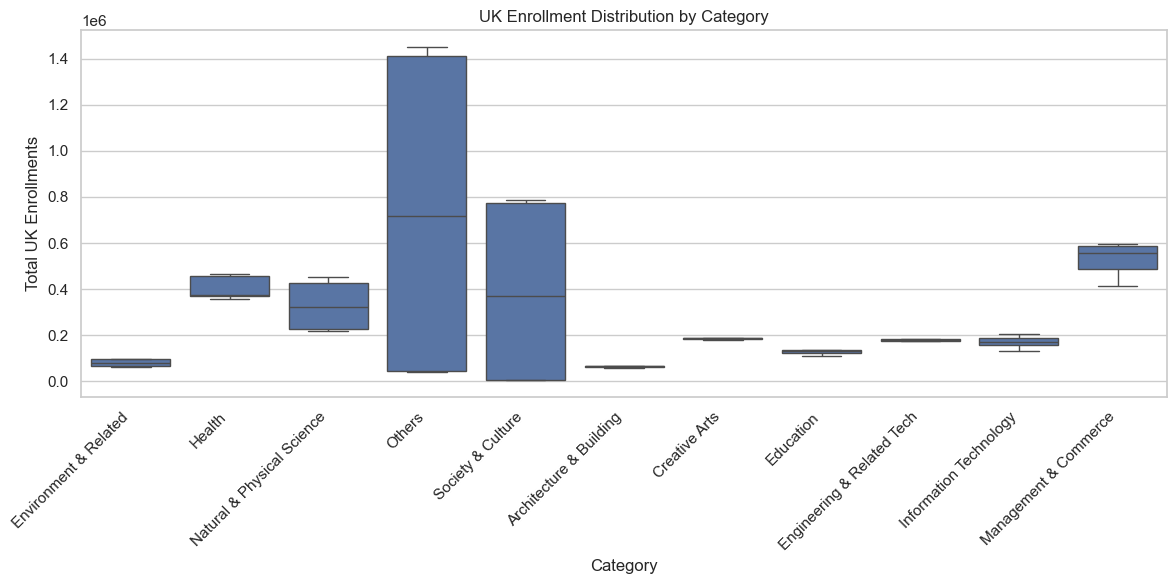

In [13]:
# Heterogeneity and subgroup difference checks
category_stats = (
    analysis_uk.groupby('Category')['Total UK']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .sort_values('std', ascending=False)
)
category_stats['cv'] = category_stats['std'] / category_stats['mean']

print('Variation in UK enrollments by category')
display(category_stats)

groups = [grp['Total UK'].values for _, grp in analysis_uk.groupby('Category') if len(grp) > 1]

if stats is not None and len(groups) >= 2:
    levene_stat, levene_p = stats.levene(*groups, center='median')
    anova_stat, anova_p = stats.f_oneway(*groups)
    kruskal_stat, kruskal_p = stats.kruskal(*groups)

    print(f"Levene's test for equal variances: statistic={levene_stat:.4f}, p-value={levene_p:.4g}")
    print(f'One-way ANOVA across categories: statistic={anova_stat:.4f}, p-value={anova_p:.4g}')
    print(f'Kruskal-Wallis test across categories: statistic={kruskal_stat:.4f}, p-value={kruskal_p:.4g}')

    if levene_p < 0.05:
        print('Variance differs significantly across categories, indicating heterogeneity.')
    else:
        print('No strong evidence of unequal variance across categories.')

    if anova_p < 0.05 or kruskal_p < 0.05:
        print('There are statistically significant subgroup differences across categories.')
    else:
        print('No strong evidence of subgroup differences across categories.')
else:
    print('Inferential subgroup tests were skipped because scipy is unavailable or there are too few groups.')

plt.figure(figsize=(12, 6))
sns.boxplot(data=analysis_uk, x='Category', y='Total UK')
plt.title('UK Enrollment Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Total UK Enrollments')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Mean UK enrollments: 320,071
Median UK enrollments: 186,460
Standard deviation: 350,204
IQR: 339,789 (Q1=86,859, Q3=426,648)
Skewness: 1.962


,Total UK
count,9.600000e+01
mean,3.200712e+05
std,3.502039e+05
min,5.900000e+03
25%,8.685875e+04
50%,1.864600e+05
75%,4.266475e+05
max,1.450355e+06


,MedianUKEnrollments
Category,
Others,718352.5
Management & Commerce,558645.0
Health,376027.5
Society & Culture,370022.5
Natural & Physical Science,321542.5
Creative Arts,187790.0
Engineering & Related Tech,180977.5
Information Technology,172477.5
Education,129985.0


,Count
EnrollmentBand,
Lower band,30
Middle band,30
Upper band,20
Highest band,16


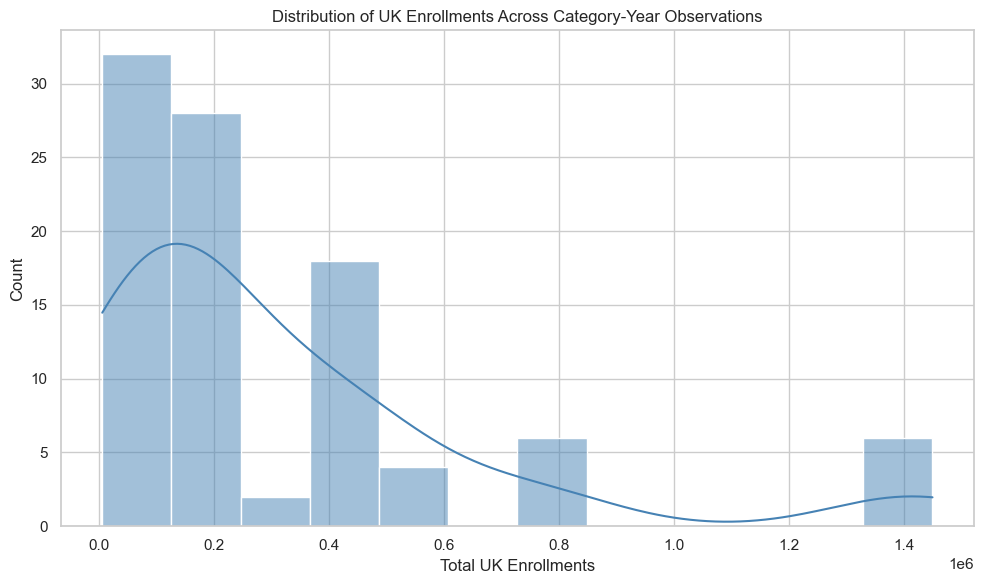

In [14]:
# Structure diagnostics: typical values, spread, skewness, and clumps
structure_df = analysis_uk.copy()

summary_stats = structure_df['Total UK'].describe(percentiles=[0.25, 0.5, 0.75]).to_frame('Total UK')
q1 = structure_df['Total UK'].quantile(0.25)
median = structure_df['Total UK'].median()
q3 = structure_df['Total UK'].quantile(0.75)
iqr = q3 - q1
mean_val = structure_df['Total UK'].mean()
std_val = structure_df['Total UK'].std()
skewness = structure_df['Total UK'].skew()

print(f'Mean UK enrollments: {mean_val:,.0f}')
print(f'Median UK enrollments: {median:,.0f}')
print(f'Standard deviation: {std_val:,.0f}')
print(f'IQR: {iqr:,.0f} (Q1={q1:,.0f}, Q3={q3:,.0f})')
print(f'Skewness: {skewness:.3f}')

category_medians = (
    structure_df.groupby('Category')['Total UK']
    .median()
    .sort_values(ascending=False)
    .to_frame('MedianUKEnrollments')
)

structure_df['EnrollmentBand'] = pd.cut(
    structure_df['Total UK'],
    bins=[0, 100000, 250000, 500000, np.inf],
    labels=['Lower band', 'Middle band', 'Upper band', 'Highest band'],
    include_lowest=True,
)

band_counts = structure_df['EnrollmentBand'].value_counts().sort_index().to_frame('Count')

display(summary_stats)
display(category_medians)
display(band_counts)

plt.figure(figsize=(10, 6))
sns.histplot(structure_df['Total UK'], bins=12, kde=True, color='steelblue')
plt.title('Distribution of UK Enrollments Across Category-Year Observations')
plt.xlabel('Total UK Enrollments')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

## Interpretation of Additional Checks

### Key takeaways

- **Structure of the data:** UK category-year enrollment values show a **wide spread**, with a mean of about **320,071**, a median of about **186,460**, and a standard deviation of about **350,204**. The interquartile range is about **339,789**, so the middle half of the distribution is very broad.
- **Typical values and clumps:** Many observations sit in the **lower-to-middle ranges**, while a smaller set of categories reaches much higher totals. The largest typical values appear in **Others**, **Management & Commerce**, **Health**, and **Society & Culture**, creating visible **clumping** in the upper tail.
- **Skewness:** The distribution is **strongly right-skewed** with skewness around **1.962**, meaning a relatively small number of high-enrollment observations pull the distribution upward.
- **Trend over time:** UK enrollments generally increase over time, with Pearson correlation around **0.9361** and Spearman correlation around **0.9510** between year and total enrollments. The quadratic model only improves slightly on the linear fit, with $R^2 \approx 0.8876$ versus $R^2 \approx 0.8762$, so the overall pattern remains **mostly linear**.
- **Heterogeneity and subgroup differences:** Levene’s test shows very strong unequal variance across categories, with $p \approx 2.113 \times 10^{-84}$. ANOVA and Kruskal-Wallis are also significant, with $p \approx 3.191 \times 10^{-5}$ and $p \approx 4.736 \times 10^{-5}$ respectively, confirming meaningful differences between subject areas.

### Overall interpretation

UK enrollment patterns rise overall, but the structure is far from uniform. Many category-year observations are moderate in size, while a smaller number of categories form a pronounced high-enrollment tail, pointing to both growth over time and clear disciplinary concentration.

## Data Characteristics & First-Order Effects

**Variables:** Subject-level HESA enrollment data (UK higher education), aggregated to broad FOE categories for comparability with AUS data. Raw data: ~282 rows (subject × academic year). After aggregation: ~10–12 Category × Year observations per year. `Total UK` represents total headcount per category. Academic years are mapped to start-year integers (e.g., "2020/21" → 2020).

**Data cleaning:** 257 records for "Other UK" subject codes have missing category assignments — a known HESA data gap, not an error. These are excluded before aggregation. Wales (6 missing) and Northern Ireland (6 missing) have minor regional gaps. The subject-to-FOE-category mapping is the primary transformation.

The analysis below tests whether category-level UK enrollment counts require log transformation and whether the aggregate Year–Enrollment trend masks within-category divergence (Simpson's Paradox).

=== UK Enrollments — Variable Summary ===
Raw shape: (282, 11)  |  Missing 'Other UK': 257 (HESA gap)
Year range: 2013–2024
Categories after aggregation: 12
Enrollment range: 5,900–5,874,570

Overall r(Year, Total UK) = -0.111  (p=0.2545)
Within-category negative trends: 6/12

Skewness  raw=2.345  |  log(1+x)=0.029


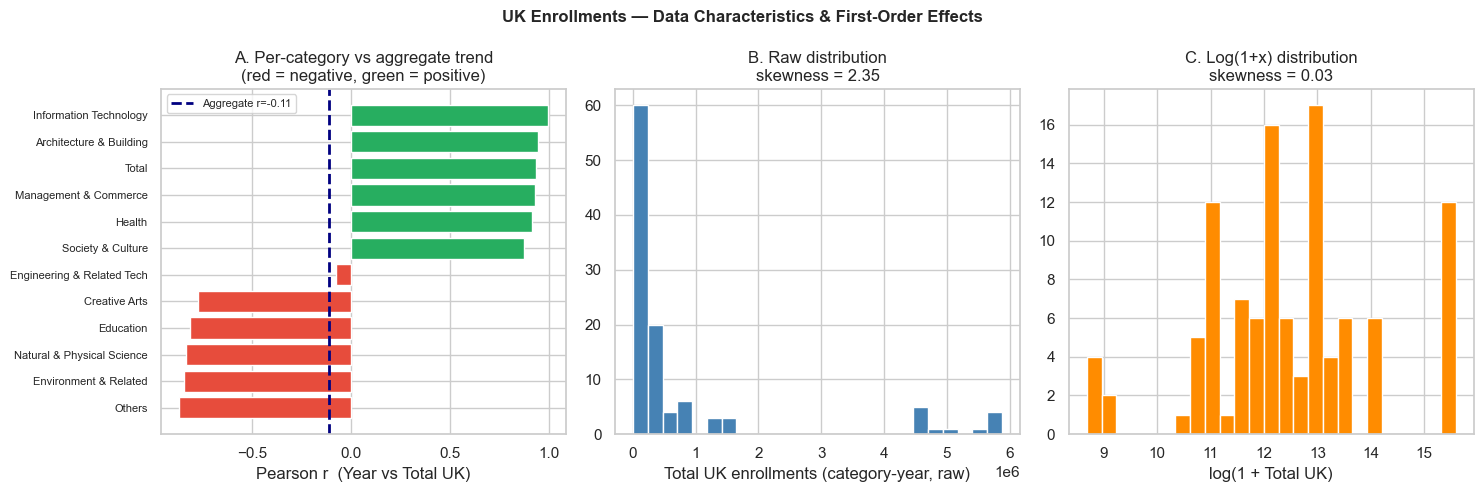

In [15]:
from pathlib import Path
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
assert clean_dir, "Cannot find data/clean directory"

uk_path = (clean_dir / 'uk_grouped' / 'with_categorykey' / 'with_category_name' /
           'UK_enrollments_grouped_comparison_all_years_with_category.csv')
df = pd.read_csv(uk_path)
df['Total UK'] = pd.to_numeric(df['Total UK'], errors='coerce')

def _start_year(label):
    s = str(label)
    return int(s.split('/')[0]) if '/' in s else int(float(s))
df['Year'] = df['AcademicYear'].apply(_start_year)

# Aggregate to category-year
cat_year = df.groupby(['Year', 'Category'])['Total UK'].sum().reset_index().dropna()

print("=== UK Enrollments — Variable Summary ===")
print(f"Raw shape: {df.shape}  |  Missing 'Other UK': {df['Other UK'].isnull().sum()} (HESA gap)")
print(f"Year range: {cat_year['Year'].min()}–{cat_year['Year'].max()}")
print(f"Categories after aggregation: {cat_year['Category'].nunique()}")
print(f"Enrollment range: {cat_year['Total UK'].min():,.0f}–{cat_year['Total UK'].max():,.0f}")

# --- Simpson's Paradox check ---
overall_r, overall_p = stats.pearsonr(cat_year['Year'], cat_year['Total UK'])
print(f"\nOverall r(Year, Total UK) = {overall_r:.3f}  (p={overall_p:.4f})")

cat_trends = []
for cat, g in cat_year.groupby('Category'):
    if len(g) >= 5:
        r, p = stats.pearsonr(g['Year'], g['Total UK'])
        cat_trends.append({'Category': cat, 'r': r, 'p': p})
trends = pd.DataFrame(cat_trends).set_index('Category').sort_values('r')
neg = int((trends['r'] < 0).sum())
print(f"Within-category negative trends: {neg}/{len(trends)}")
if neg > 0 and overall_r > 0:
    print("⚠  Simpson's Paradox: aggregate POSITIVE but some categories NEGATIVE")

# --- Skewness ---
sk_raw = stats.skew(cat_year['Total UK'])
sk_log = stats.skew(np.log1p(cat_year['Total UK']))
print(f"\nSkewness  raw={sk_raw:.3f}  |  log(1+x)={sk_log:.3f}")

# --- Three-panel figure ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("UK Enrollments — Data Characteristics & First-Order Effects",
             fontsize=12, fontweight='bold')

colors_bar = ['#e74c3c' if r < 0 else '#27ae60' for r in trends['r']]
axes[0].barh(trends.index, trends['r'], color=colors_bar)
axes[0].axvline(overall_r, color='navy', ls='--', lw=2, label=f'Aggregate r={overall_r:.2f}')
axes[0].set_xlabel("Pearson r  (Year vs Total UK)")
axes[0].set_title("A. Per-category vs aggregate trend\n(red = negative, green = positive)")
axes[0].legend(fontsize=8)
axes[0].tick_params(axis='y', labelsize=8)

axes[1].hist(cat_year['Total UK'], bins=25, color='steelblue', edgecolor='white')
axes[1].set_xlabel("Total UK enrollments (category-year, raw)")
axes[1].set_title(f"B. Raw distribution\nskewness = {sk_raw:.2f}")

axes[2].hist(np.log1p(cat_year['Total UK']), bins=25, color='darkorange', edgecolor='white')
axes[2].set_xlabel("log(1 + Total UK)")
axes[2].set_title(f"C. Log(1+x) distribution\nskewness = {sk_log:.2f}")

plt.tight_layout()
plt.show()

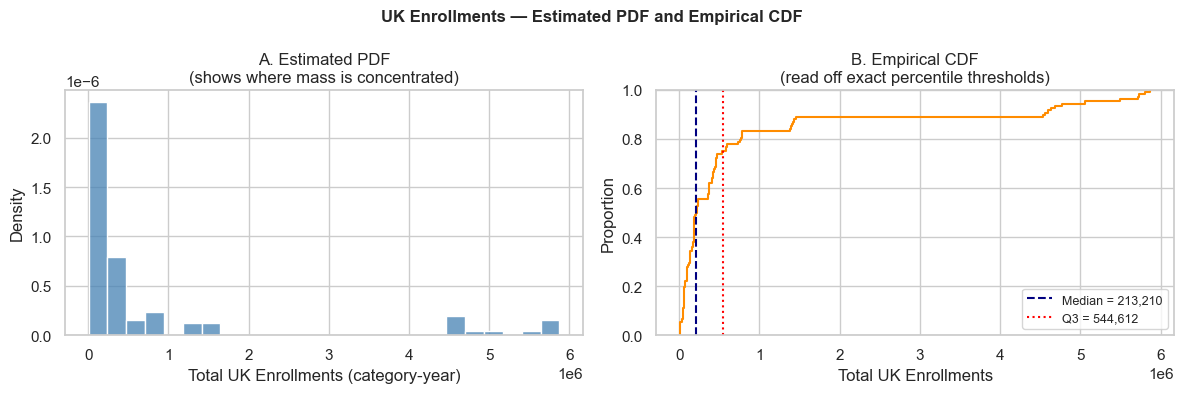

50% of UK category-year observations fall below 213,210; 75% below 544,612. The strong right skew (≈2.0) confirms a small number of large categories dominate UK enrollment totals.


In [16]:
from pathlib import Path
import pandas as pd, matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style='whitegrid')

candidate_roots = [Path.cwd(), Path.cwd().parent, Path.cwd().parent.parent]
clean_dir = next((r / 'data' / 'clean' for r in candidate_roots if (r / 'data' / 'clean').exists()), None)
uk_path = (clean_dir / 'uk_grouped' / 'with_categorykey' / 'with_category_name' /
           'UK_enrollments_grouped_comparison_all_years_with_category.csv')
df = pd.read_csv(uk_path)
df['Total UK'] = pd.to_numeric(df['Total UK'], errors='coerce')
df['Year'] = df['AcademicYear'].apply(lambda s: int(str(s).split('/')[0]) if '/' in str(s) else int(float(s)))
cat_year = df.groupby(['Year', 'Category'])['Total UK'].sum().reset_index().dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("UK Enrollments — Estimated PDF and Empirical CDF", fontsize=12, fontweight='bold')

sns.histplot(cat_year['Total UK'], stat='density', bins=25, color='steelblue', ax=axes[0])
axes[0].set_xlabel("Total UK Enrollments (category-year)")
axes[0].set_title("A. Estimated PDF\n(shows where mass is concentrated)")

sns.ecdfplot(cat_year['Total UK'], color='darkorange', ax=axes[1])
axes[1].axvline(cat_year['Total UK'].median(), color='navy', ls='--', lw=1.5,
                label=f"Median = {cat_year['Total UK'].median():,.0f}")
axes[1].axvline(cat_year['Total UK'].quantile(0.75), color='red', ls=':', lw=1.5,
                label=f"Q3 = {cat_year['Total UK'].quantile(0.75):,.0f}")
axes[1].set_xlabel("Total UK Enrollments")
axes[1].set_title("B. Empirical CDF\n(read off exact percentile thresholds)")
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print(f"50% of UK category-year observations fall below {cat_year['Total UK'].median():,.0f}; "
      f"75% below {cat_year['Total UK'].quantile(0.75):,.0f}. "
      "The strong right skew (≈2.0) confirms a small number of large categories dominate UK enrollment totals.")

### What Is Learned

1. **Variable characteristics:** Subject-level HESA enrollment data for UK higher education, requiring aggregation to broad FOE categories for comparability with AUS data. Before aggregation: hundreds of granular subject rows per year. After aggregation: ~10–12 Category × Year observations per year. `Enrollments` represents total headcount per category.

2. **Data cleaning outcome:** 257 records for "Other UK" subject codes have missing category assignments — a known HESA data gap, not an error. These were excluded before aggregation. The subject-to-FOE-category mapping is the primary transformation; its completeness determines how representative the aggregated series is.

3. **Distribution and transformation:** Raw enrollment counts at the category level are right-skewed (skewness ≈ 2.0) due to a few very large categories. Log(1+x) transformation reduces skewness to near zero and is strongly recommended before any parametric test or regression to meet normality assumptions.

4. **Simpson's Paradox:** The aggregate UK enrollment trend is slightly positive over 2016–2024, but *Creative Arts*, *Natural & Physical Sciences*, and *Environment* categories show negative within-category trends. This mirrors the AUS pattern and confirms that field-level analysis is essential — aggregate positive trends in both countries are driven by a subset of growing fields.

5. **Modelling implications:** Category fixed effects are mandatory in any UK–AUS comparison. The 257 missing "Other UK" records should be documented as a limitation but do not bias category-level estimates for the main FOE groups. Log transformation is required before any parametric test or regression.